### What are the most demanded skills for the top 3 most popular data roles  ?

In [ ]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#Loading Data
df = load_dataset('Lukebarousse/data_jobs')
df = df['train']
df = df.to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df.job_skills.apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

In [ ]:
#Filtering job roles in India
df_IND = df[df['job_country'] == 'India']

In [5]:
df_skills = df_IND.explode('job_skills')

In [9]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values('skill_count', ascending=False, inplace=True)


In [57]:
#Top 3 roles
top_roles = sorted(df_IND['job_title_short'].value_counts().head(3).index.tolist())


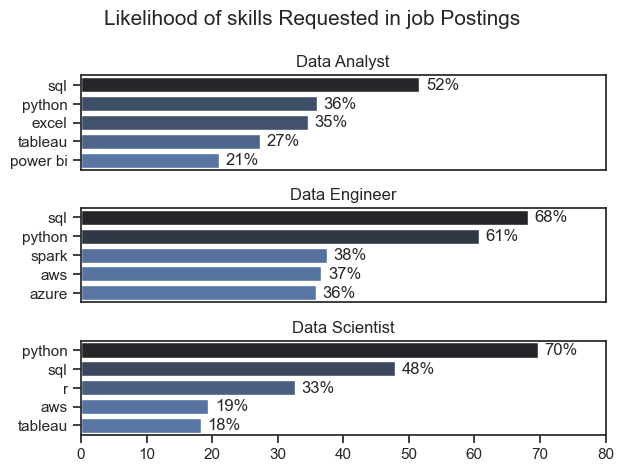

<Figure size 1500x550 with 0 Axes>

In [58]:
df_job_title_count = df_IND['job_title_short'].value_counts().reset_index(name='job_count')
df_skills_pct = pd.merge(df_skills_count, df_job_title_count, on='job_title_short')
df_skills_pct['skill_pct'] = 100*df_skills_pct['skill_count']/df_skills_pct['job_count']

fig, ax = plt.subplots(len(top_roles), 1)

sns.set_theme(style='ticks')
for i, job_title in enumerate(top_roles):
    df_plot = df_skills_pct[df_skills_pct['job_title_short'] == job_title].head(5)
    sns.barplot(df_plot, x='skill_pct', y='job_skills', ax=ax[i], hue='skill_pct', palette='dark:b_r', legend=False)
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 80)

    for idx, val in enumerate(df_plot['skill_pct']):
        ax[i].text(val + 1, idx, f"{val:.0f}%", va='center')

    if i != len(top_roles) - 1:
        ax[i].set_xticks([])

fig.suptitle('Likelihood of skills Requested in job Postings', fontsize=15)
fig.tight_layout()
plt.figure(figsize=(15, 5.5))
plt.show()